In [13]:
from pathlib import Path
import json
from typing import cast, Dict, List
import testing
from run_types import CompRes
import pandas as pd      # not imported previously, so do it here
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np


In [14]:
exps_dict_path = Path('./results/wlasl_saicist.json')
print(exps_dict_path.exists())

True


In [15]:
with open(exps_dict_path, 'r') as f:
    exps_dict = json.load(f)

In [16]:

print(len(exps_dict['asl100']))

2


In [17]:
exps_dict = cast(Dict[str, Dict[str, List[str]]], exps_dict)

In [18]:
from typing import Any
def sort_dict(dict: Dict[str, Any]) -> Dict[str, Any]:
    return {key : value for key, value in sorted(dict.items(), key=lambda x: x[0])}

In [19]:
for key, value in exps_dict.items():
    exps_dict[key] = sort_dict(value)

In [20]:
total_summarised = {}
for split, asl_exps in exps_dict.items():
    runs_dir = Path('./runs') / split
    
    summarised = {}
    for model_name, exps in asl_exps.items():
        expno = exps[0]
        print(f'{model_name} : {expno}')
        results_path = runs_dir / f'{model_name}_exp{expno}' / 'results' / 'best_val_loss.json'
        with open(results_path, 'r') as f:
            entry_res = cast(CompRes, json.load(f))
        

        res_key = "top_k_average_per_class_acc"

        summarised[model_name] = {
            'exp': expno,
            res_key : entry_res['test'][res_key]
        }

    total_summarised[split] = summarised

exps_summarised_dict_path = exps_dict_path.parent / exps_dict_path.name.replace('.json', '_summarised.json')
with open(exps_summarised_dict_path, 'w') as f:
    json.dump(total_summarised, f, indent=4)

MViTv2_S : 010
S3D : 046
MViTv2_S : 001
S3D : 002
MViTv2_S : 000
S3D : 000
MViTv2_S : 000
S3D : 000


In [21]:
def get_data_frame(split_sum: Dict[str, Dict[str, Dict[str, float]]]) -> pd.DataFrame:
    rows = []
    acc_key = "top_k_average_per_class_acc"
    top1, top5, top10 = 'top1', 'top5', 'top10'
    for model_name, res_d in split_sum.items():
        rows.append({
            'Model': model_name,
            top1: res_d[acc_key][top1],
            top5: res_d[acc_key][top5],
            top10: res_d[acc_key][top10],
        })
    return pd.DataFrame(rows)

In [22]:
for split, summarised in total_summarised.items():
    print(f'{split}')
    display(get_data_frame(summarised))
    # print(get_data_frame(summarised))
    
    

asl100


,Model,top1,top5,top10
0,MViTv2_S,0.741000,0.921667,0.948333
1,S3D,0.500167,0.781333,0.868833


asl300


,Model,top1,top5,top10
0,MViTv2_S,0.662722,0.892111,0.936944
1,S3D,0.524778,0.786556,0.872389


asl1000


,Model,top1,top5,top10
0,MViTv2_S,0.533133,0.817167,0.877500
1,S3D,0.363200,0.678183,0.769167


asl2000


,Model,top1,top5,top10
0,MViTv2_S,0.355025,0.69265,0.782900
1,S3D,0.176183,0.44055,0.552883


Saved to: /home/luke/Code/SLR/code/results/bar_all_splits.pdf


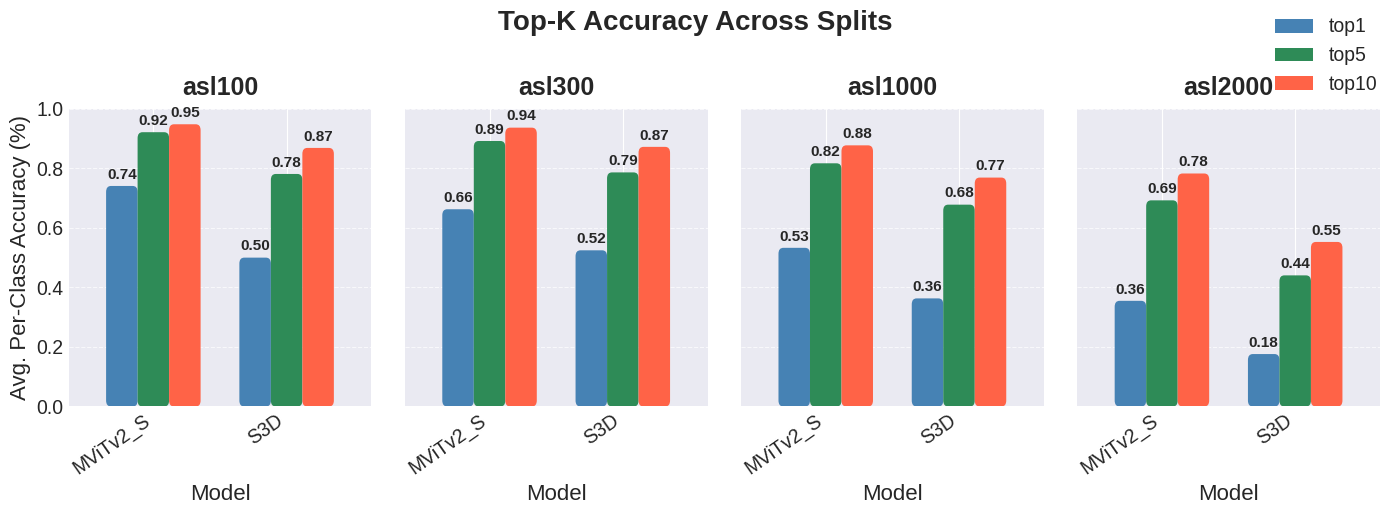

In [23]:
def plot_all_splits(total_summarised: Dict[str, Dict[str, Dict[str, float]]]):
    import os
    from matplotlib.patches import FancyBboxPatch
    os.makedirs('results', exist_ok=True)

    n_splits = len(total_summarised)
    fig, axes = plt.subplots(1, n_splits, figsize=(3.5 * n_splits, 5), sharey=True)

    if n_splits == 1:
        axes = [axes]

    width = 0.13  # thinner bars
    radius = 0.02  # rounding radius — increase for more pronounced rounding
    colors = {'top1': 'steelblue', 'top5': 'seagreen', 'top10': 'tomato'}

    def draw_rounded_bar(ax, x, y, width, color, radius):
        """Draw a single rounded bar using FancyBboxPatch."""
        box = FancyBboxPatch(
            (x - width / 2, 0), width, y,
            boxstyle=f"round,pad=0,rounding_size={radius}",
            linewidth=0, color=color
        )
        ax.add_patch(box)

    for ax, (split_name, split_sum) in zip(axes, total_summarised.items()):
        df = get_data_frame(split_sum)
        models = df['Model']
        x = np.arange(len(models)) * 0.55  # very tight group spacing

        for i, (metric, color) in enumerate(colors.items()):
            offset = (i - 1) * width
            for j, val in enumerate(df[metric]):
                draw_rounded_bar(ax, x[j] + offset, val, width, color, radius)
                ax.annotate(f'{val:.2f}',
                            xy=(x[j] + offset, val),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=11, fontweight='bold')

        # Dummy bars for the legend
        for metric, color in colors.items():
            ax.bar(0, 0, color=color, label=metric)

        ax.set_title(split_name, fontsize=18, fontweight='bold', pad=10)
        ax.set_xlabel('Model', fontsize=16)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=35, ha='right', fontsize=14)
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
        ax.tick_params(axis='y', labelsize=14)
        ax.set_axisbelow(True)
        ax.set_xlim(x[0] - 0.35, x[-1] + 0.35)
        ax.set_ylim(0, 1.0)

    axes[0].set_ylabel('Avg. Per-Class Accuracy (%)', fontsize=16)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=14)
    fig.suptitle('Top-K Accuracy Across Splits', fontsize=20, fontweight='bold', y=1.02)

    plt.tight_layout()

    output_path = 'results/bar_all_splits.pdf'
    plt.savefig(output_path, bbox_inches='tight')
    print(f"Saved to: {os.path.abspath(output_path)}")
    plt.show()

plot_all_splits(total_summarised)

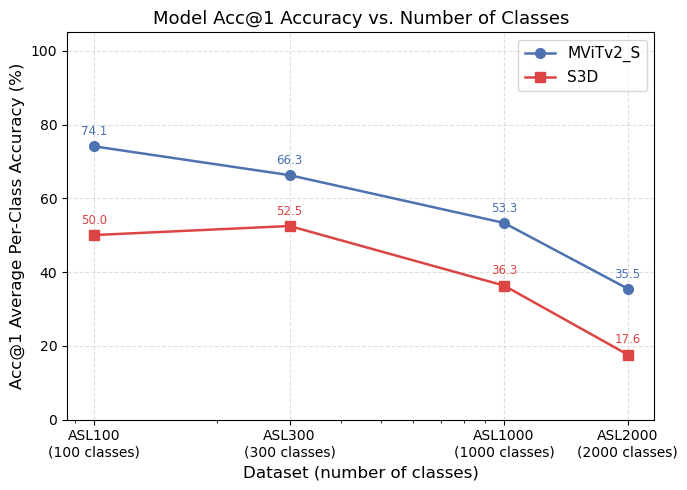

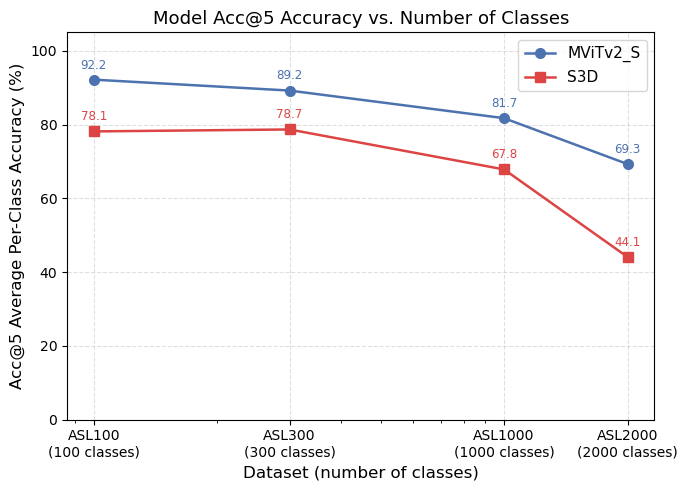

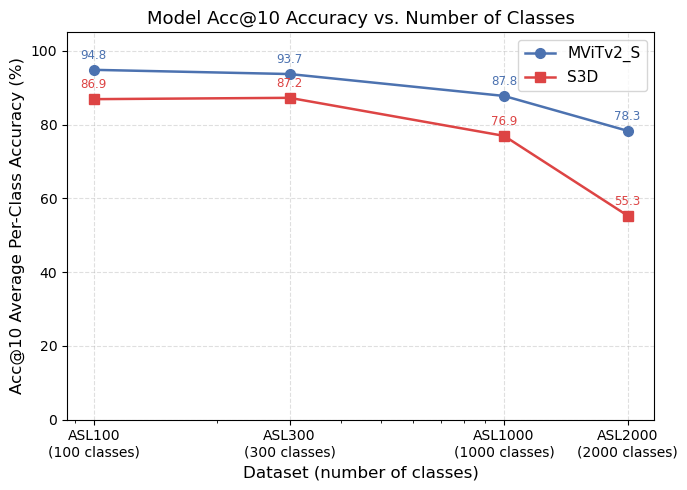

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your table
n_classes = [100, 300, 1000, 2000]

data = {
    "MViTv2_S": {
        "top1":  [74.10, 66.27, 53.31, 35.50],
        "top5":  [92.17, 89.21, 81.72, 69.27],
        "top10": [94.83, 93.69, 87.75, 78.29],
    },
    "S3D": {
        "top1":  [50.02, 52.48, 36.32, 17.62],
        "top5":  [78.13, 78.66, 67.82, 44.06],
        "top10": [86.88, 87.24, 76.92, 55.29],
    },
}

model_styles = {
    "MViTv2_S": {"color": "#4C72B0", "marker": "o"},
    "S3D":      {"color": "#DD4444", "marker": "s"},
}

top_k_labels = {"top1": "Acc@1", "top5": "Acc@5", "top10": "Acc@10"}

for k, k_label in top_k_labels.items():
    fig, ax = plt.subplots(figsize=(7, 5))

    for model_name, metrics in data.items():
        style = model_styles[model_name]
        ax.plot(
            n_classes, metrics[k],
            marker=style["marker"],
            color=style["color"],
            linewidth=1.8,
            markersize=7,
            label=model_name,
        )
        # Annotate each point with its value
        for x, y in zip(n_classes, metrics[k]):
            ax.annotate(
                f"{y:.1f}",
                xy=(x, y),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                fontsize=8.5,
                color=style["color"],
            )

    ax.set_xscale("log")
    ax.set_xticks(n_classes)
    ax.set_xticklabels([f"ASL{n}\n({n} classes)" for n in n_classes])
    ax.set_xlabel("Dataset (number of classes)", fontsize=12)
    ax.set_ylabel(f"{k_label} Average Per-Class Accuracy (%)", fontsize=12)
    ax.set_title(f"Model {k_label} Accuracy vs. Number of Classes", fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_ylim(0, 105)

    plt.tight_layout()
    plt.savefig(f"{k}_vs_classes.png", dpi=150)
    plt.show()

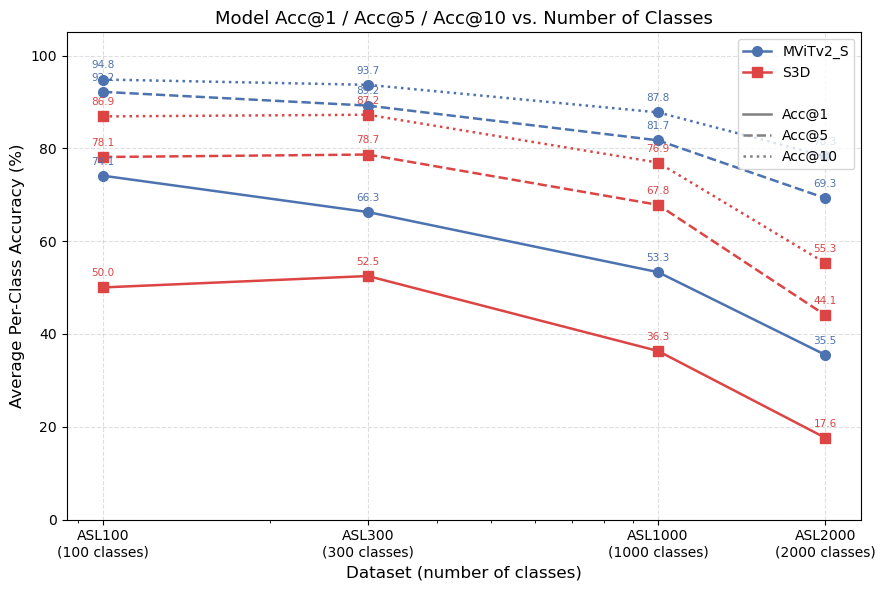

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_classes = [100, 300, 1000, 2000]

data = {
    "MViTv2_S": {
        "top1":  [74.10, 66.27, 53.31, 35.50],
        "top5":  [92.17, 89.21, 81.72, 69.27],
        "top10": [94.83, 93.69, 87.75, 78.29],
    },
    "S3D": {
        "top1":  [50.02, 52.48, 36.32, 17.62],
        "top5":  [78.13, 78.66, 67.82, 44.06],
        "top10": [86.88, 87.24, 76.92, 55.29],
    },
}

model_styles = {
    "MViTv2_S": {"color": "#4C72B0", "marker": "o"},
    "S3D":      {"color": "#DD4444", "marker": "s"},
}

topk_styles = {
    "top1":  {"linestyle": "-",  "label": "Acc@1"},
    "top5":  {"linestyle": "--", "label": "Acc@5"},
    "top10": {"linestyle": ":",  "label": "Acc@10"},
}

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, metrics in data.items():
    style = model_styles[model_name]
    for k, tk_style in topk_styles.items():
        ax.plot(
            n_classes, metrics[k],
            marker=style["marker"],
            color=style["color"],
            linestyle=tk_style["linestyle"],
            linewidth=1.8,
            markersize=7,
            label=f"{model_name} {tk_style['label']}",
        )
        for x, y in zip(n_classes, metrics[k]):
            ax.annotate(
                f"{y:.1f}",
                xy=(x, y),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                fontsize=7.5,
                color=style["color"],
            )

ax.set_xscale("log")
ax.set_xticks(n_classes)
ax.set_xticklabels([f"ASL{n}\n({n} classes)" for n in n_classes])
ax.set_xlabel("Dataset (number of classes)", fontsize=12)
ax.set_ylabel("Average Per-Class Accuracy (%)", fontsize=12)
ax.set_title("Model Acc@1 / Acc@5 / Acc@10 vs. Number of Classes", fontsize=13)
ax.set_ylim(0, 105)
ax.grid(True, linestyle="--", alpha=0.4)

# Two-level legend: group by model (color) and by metric (linestyle)
from matplotlib.lines import Line2D
legend_elements = [
    # Models
    Line2D([0], [0], color="#4C72B0", marker="o", linewidth=1.8, markersize=7, label="MViTv2_S"),
    Line2D([0], [0], color="#DD4444", marker="s", linewidth=1.8, markersize=7, label="S3D"),
    # Spacer
    Line2D([0], [0], color="none", label=""),
    # Top-k
    Line2D([0], [0], color="grey", linestyle="-",  linewidth=1.8, label="Acc@1"),
    Line2D([0], [0], color="grey", linestyle="--", linewidth=1.8, label="Acc@5"),
    Line2D([0], [0], color="grey", linestyle=":",  linewidth=1.8, label="Acc@10"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("topk_vs_classes.pdf", dpi=150)
plt.show()